k-Nearest Neighbors (kNN)
Classifica un punto x in base alla alle etichette dei k vicini più prossimi nel dataset etichettato. L'etichetta assegnata a x sarà quella più frequente tra le k.

Non c'è apprendimento. Risulta essere molto semplice ed efficace ma la classificazione è costosa. Inoltre richiede la memorizzazione dell'intero dataset di apprendimento.

Codifica
Il fitting consiste nel memorizzare i dati etichettati. Il predict richiede la ricerca dei k vicini più prossimi rispetto ad una funzione distanza che di default è quella euclidea; si usa una variante del selection sort che garantisce complessità lineare nella dimensione del dataset di apprendimento (se si assume k costante). Questa può diventare logaritmica se si usano strutture dati ad albero binario per memorizzare gli esempi del dataset di apprendimento (ad esempio di kd-tree).

In [1057]:
# import delle librerie

import numpy as np  # libreria per calcolo vettoriale... ma non solo
import matplotlib.pyplot as plt  # librerie per il disegno
import matplotlib.patches as patches

Esempi di utilizzo delle precedenti librerie
Gli array di numpy sono utilizzati per descrivere matrici o vettori delle features.

In [1058]:
center = np.array([0,0])   # un array di due elementi

# una matrice di 11 righe e 3 colonne
points = np.array([[0.5, 0.5, 1], [0.6, 1.16, 1], [1.14, 0.8, 1], [-1.1, -1.0, 1], [1.01, -0.9, 1],
                   [0.3, 0.5, 0], [-0.6, 0.6, 0], [0.2, -0.7, 0], [-0.8, -0.2, 0], [1.0, -0.5, 0], [-1.5, 0.1, 0]])

Qualche esempio di utilizzo delle strutture precedentemente create

In [1059]:
print(points)

[[ 0.5   0.5   1.  ]
 [ 0.6   1.16  1.  ]
 [ 1.14  0.8   1.  ]
 [-1.1  -1.    1.  ]
 [ 1.01 -0.9   1.  ]
 [ 0.3   0.5   0.  ]
 [-0.6   0.6   0.  ]
 [ 0.2  -0.7   0.  ]
 [-0.8  -0.2   0.  ]
 [ 1.   -0.5   0.  ]
 [-1.5   0.1   0.  ]]


In [1060]:
print(points[2, 1])

0.8


In [1061]:
print( points[3:6,1] ) # slicing

[-1.  -0.9  0.5]


In [1062]:
print( points[:, 1])   # slicing

[ 0.5   1.16  0.8  -1.   -0.9   0.5   0.6  -0.7  -0.2  -0.5   0.1 ]


In [1063]:
a = np.arange(3, 11)
print(a)
print(a[ [1,6, 4] ]) # operazione di filtro

[ 3  4  5  6  7  8  9 10]
[4 9 7]


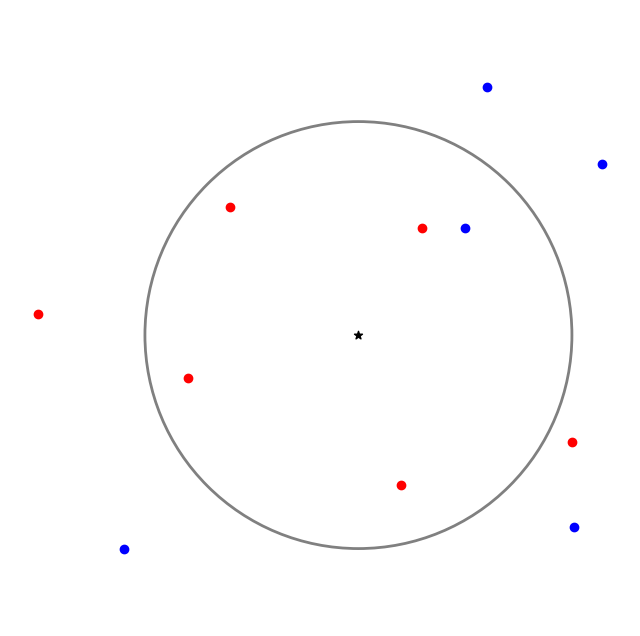

In [1064]:
# ridefiniamo center e points solo per rendere questa cella indipendente dalla precedente
center = np.array([0,0])
points = np.array([[0.5, 0.5, 1], [0.6, 1.16, 1], [1.14, 0.8, 1], [-1.1, -1.0, 1],
                   [1.01, -0.9, 1], [0.3, 0.5, 0], [-0.6, 0.6, 0], [0.2, -0.7, 0],
                   [-0.8, -0.2, 0], [1.0, -0.5, 0], [-1.5, 0.1, 0]])

fig, ax = plt.subplots(figsize=(8, 8))   # nuova figura di dimensione 8x8

ax.scatter(center[0], center[1], color='black', marker='*')   # disegno del punto al centro come una stella
circle = patches.Circle(center, 1, edgecolor='gray', facecolor= None, alpha=1, linewidth=2, fill=False)   # definisce cerchio centrato in center

# disegna i punti con etichetta 1 definendo la lista delle coordinate x e y usando
# list comprehension (vedere)
ax.scatter([x for x,y,t in points if t == 1], [y for x,y,t in points if t == 1], color = 'blue', marker='o')
# stessa cosa con etichetta 0
ax.scatter([x for x,y,t in points if t == 0], [y for x,y,t in points if t == 0], color = 'red', marker='o')

# aggiunge cenchio al disegno
ax.add_patch(circle)
ax.axis('equal')
ax.axis('off')

# salve disegno
plt.savefig('01-28-knn.png', dpi=120, bbox_inches='tight')

plt.show()

Definizione della classe

In [1065]:
class KNN(object):
    def __init__(self, k = 5, distance = None):
        self.k = k
        if distance == None:
            self._dist = euclidean_dist
        else:
            self._dist = distance
    
    def fit(self, X, y):
        self.X = X  # X è una matrice n x d (n campioni, d features)
        self.y = y  # y è un array di dimensione n
        
    def predict(self, x):        
        # Ottiene gli indici dei k punti più vicini
        k_indices = selection_sort(self.X, x, k=5, key = self._dist)
        
        # Prende le etichette corrispondenti
        return mode(self.y[k_indices])

Le funzioni
euclidean_dist, selection_sort e  mode devono essere definite.

La lunghezza del vettore a0 - a1

In [1066]:
def euclidean_dist(a0, a1):
    return np.linalg.norm(a0 - a1)

Trova i primi k elementi in ordine di grandezza nell'array a.

La funzione da minimizzare è key, funzione di a e x (p.e. la distanza da x agli elementi di a)

In [1067]:
def selection_sort(a, x, k = None, key = None):
    '''
    input: a, una sequenza; x un oggetto, k un intero; key una funzione dei valori di a e x
    
    restituisce un array con i primi k elementi di a in ordine di grandezza rispetto
    alla funzione key

    se k non indicato, viene usata per k la dimensione dell'array

    se key non indicato, viene usata la funzione identità 
    '''
    if k == None or k > len(a) or k < 0:
        k = len(a)
    if key == None:
        key = lambda y, _: y
        
    idxs = [] # idxs[:i] le posizioni dei primi i elementi di a in ordine di grandezza 
        
    for i in range(k):  # eseguito k volte
        # cerchiamo idxs[k]
        m = None # il valore del candidato
        for j, v in enumerate(a): # eseguito n volte (dove n = len(a)) 
            if m == None or key(v, x) < key(a[m], x):  # tempo costante O(1)
                if j not in idxs:  # O(k) può diventare  costante O(1) se si usa un set
                    m = j

        # costo del for interno O(kn)
        idxs.append(m)  # O(1)

    # costo totale è O(nk) (con set) se k piccolo il tempo è lineare
            
    return idxs

Assumiamo che len(a) sia n.

Se k è piccolo, l'algoritmo è effiente, richiede  
Θ
(
k
n
)
  operazioni
Le operazioni potrebbero scendere  
Θ
(
k
log
n
)
  se impieghiamo la struttura dati k-d tree
Il numero di operazioni per costruire l'albero è  
Θ
(
n
log
2
n
)
 
La funzione mode calcola la moda di un array-like, ovvero l'elemento più frequente, ritornando l'elemento ed il numero di volte in cui compare.

In [1068]:
def mode( a ):
    '''
    parametro: a, un array-like

    return: l'elemento più frequente ed il numero di occorrenze
    '''

    # lista di elementi senza ripetizioni, numero di occorrenze
    itms, cnts = np.unique(np.array(a), return_counts=True ) 

    return itms[np.argmax(cnts)], max(cnts)

IRIS

In [1069]:
import os
import pandas as pd

s = os.path.join('dataset', '01-02-iris.csv')
df = pd.read_csv(s, header=None, encoding='utf-8')

In [1070]:
df

,0,1,2,3,4
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [1071]:
X = df.iloc[:, [0,1]].values
y = df.iloc[:, 4].values

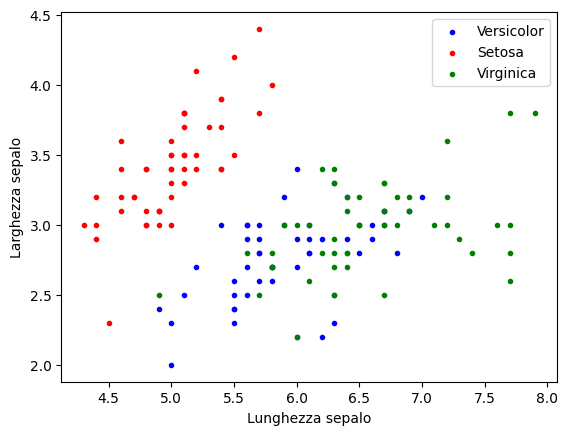

In [1072]:
versicolor = X[np.where(y == 'Iris-versicolor')]
setosa = X[np.where(y == 'Iris-setosa')]
virginica = X[np.where(y == 'Iris-virginica')]

plt.scatter(versicolor[:,0], versicolor[:,1], color='blue', marker='.', label='Versicolor')
plt.scatter(setosa[:,0], setosa[:,1], color='red', marker='.', label='Setosa')
plt.scatter(virginica[:,0], virginica[:,1], color='green', marker='.', label='Virginica')
plt.xlabel('Lunghezza sepalo')
plt.ylabel('Larghezza sepalo')
plt.legend()

plt.savefig('01-24-iris_01.png', dpi=120, bbox_inches='tight')

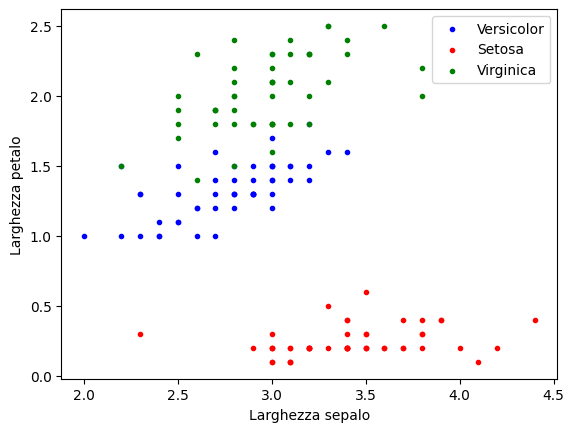

In [1073]:
X = df.iloc[:, [1,3]].values
y = df.iloc[:, 4].values

versicolor = X[np.where(y == 'Iris-versicolor')]
setosa = X[np.where(y == 'Iris-setosa')]
virginica = X[np.where(y == 'Iris-virginica')]

plt.scatter(versicolor[:,0], versicolor[:,1], color='blue', marker='.', label='Versicolor')
plt.scatter(setosa[:,0], setosa[:,1], color='red', marker='.', label='Setosa')
plt.scatter(virginica[:,0], virginica[:,1], color='green', marker='.', label='Virginica')
plt.xlabel('Larghezza sepalo')
plt.ylabel('Larghezza petalo')

plt.legend()

plt.savefig('01-26-iris_13.png', dpi=120, bbox_inches='tight')

Classificazione e testing di KNN
Il dataset viene diviso in due perti, training set e test set. Il primo viene utilizzato per addestrare il classificatore (nel caso di KNN, solo memorizzazione dati). Il secondo viene utilizzato per verificare il modello, si classificano i dati usando l'algoritmo e si confrontano i risultati con le etichette reali.

Funzione di split

In [ ]:
'''def train_test_split(X, y, train_size = 0.7):
    n = X.shape[0]
    train_idxs = np.random.choice(n, size = int(n*train_size), replace=False)
    test_idxs =  np.setdiff1d(np.arange(n), train_idxs)
    return X[train_idxs], y[train_idxs], X[test_idxs], y[test_idxs]'''

def train_test_split(X, y, train_size = 0.5):
    n = X.shape[0]
    classi=[]
    for etichetta in y:
        if etichetta not in classi:
            classi.append(etichetta)
    train_idxs = []       
    for cls in classi:
        indici = []
        for i in range(len(y)):
            if y[i] == cls:
                indici.append(i)
        scelti = np.random.choice(indici, size = int(len(indici)*train_size), replace=False)
        train_idxs.extend(scelti)
    test_idxs =  np.setdiff1d(np.arange(n), train_idxs)
    
    return X[train_idxs], y[train_idxs], X[test_idxs], y[test_idxs]


In [1075]:
X = df.iloc[:, :-1].values  # i valori in tutte le riche e tutte le colonne tranne l'ultima
y = df.iloc[:, 4].values # i valori nell'ultima colonna
#y = df.iloc[:, -1].values # alteternativa alla precedente

X_train, y_train, X_test, y_test = train_test_split(X, y)

Definizione di una nuova istanza del modello KNN

In [1076]:
knn = KNN()
knn.fit(X_train, y_train)

In [1077]:
x, t = X_test[0], y_test[0] 
print(knn.predict(x), t)

('Iris-setosa', np.int64(5)) Iris-setosa


In [1078]:
for x, t in zip(X_test[:10], y_test[:10]):
    print(x,t, knn.predict(x))

[4.9 3.  1.4 0.2] Iris-setosa ('Iris-setosa', np.int64(5))
[4.6 3.1 1.5 0.2] Iris-setosa ('Iris-setosa', np.int64(5))
[5.  3.6 1.4 0.2] Iris-setosa ('Iris-setosa', np.int64(5))
[5.4 3.9 1.7 0.4] Iris-setosa ('Iris-setosa', np.int64(5))
[4.6 3.4 1.4 0.3] Iris-setosa ('Iris-setosa', np.int64(5))
[5.  3.4 1.5 0.2] Iris-setosa ('Iris-setosa', np.int64(5))
[4.4 2.9 1.4 0.2] Iris-setosa ('Iris-setosa', np.int64(5))
[4.9 3.1 1.5 0.1] Iris-setosa ('Iris-setosa', np.int64(5))
[5.4 3.7 1.5 0.2] Iris-setosa ('Iris-setosa', np.int64(5))
[4.8 3.4 1.6 0.2] Iris-setosa ('Iris-setosa', np.int64(5))


Valutazione

In [1079]:
[knn.predict(x)[0] for x in X_test]

['Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-virginica',
 'Iris-virginica',
 'Iris-virginica',
 'Iris-versicolor',
 'Iris-virginica',
 'Ir

In [1080]:
# Booleano contenente l'esito dei confronti tra etichette reali e predette
preds = np.array([knn.predict(x)[0] for x in X_test]) == y_test
print(preds)

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True False  True  True  True  True  True  True
  True  True  True  True  True  True False  True  True False  True  True
  True  True  True]


Accuratezza

In [1081]:
print('Accuratezza: ', np.sum(preds)/preds.shape[0] )   # oppure np.sum(preds)/len(preds) 

Accuratezza:  0.96
